In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR

from google.colab import drive  # datasets saved in personal google drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Step 1: Big Data - Datasets Preview:**

- Daily BTC (Bitcoin) data
- Transactional-level USDT (Tether) data - over 560k rows
- Time periods: Jan 1, 2018 ~ Mar 31, 2018

In [80]:
btc = pd.read_csv('/content/drive/MyDrive/Colab/Fin_Econ/Data/EOD_BTC_data.csv')
tether = pd.read_csv('/content/drive/MyDrive/Colab/Fin_Econ/Data/Tether_Q1_2018.csv')

# Data preview on rows and columns

print("--- BTC Data First 5 Rows & Columns Summary ---")
print(btc.head())
print("\n")
print(btc.info())

print("\n")

print("--- Tether Data First 5 Rows & Columns Summary ---")
print(tether.head())
print("\n")
print(tether.info())

--- BTC Data First 5 Rows & Columns Summary ---
         Date       Open       High        Low      Close          Volume  \
0  2018-01-01  14,112.20  14,112.20  13,154.70  13,657.20  10,291,200,000   
1  2018-01-02  13,625.00  15,444.60  13,163.60  14,982.10  16,846,600,192   
2  2018-01-03  14,978.20  15,572.80  14,844.50  15,201.00  16,871,900,160   
3  2018-01-04  15,270.70  15,739.70  14,522.20  15,599.20  21,783,199,744   
4  2018-01-05  15,477.20  17,705.20  15,202.80  17,429.50  23,840,899,072   

        Market Cap  EOD_Return  
0  229,119,155,396    -0.03526  
1  251,377,913,955     0.09701  
2  255,080,562,912     0.01461  
3  261,795,321,110     0.02620  
4  292,544,135,538     0.11733  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        90 non-null     object 
 1   Open        90 non-null     object 
 2   High        90 non

In [81]:
tether_df = tether.copy()

print("--- Tether Data: In-depth Analysis of Key Column Content ---")

# (1) Transaction Type Analysis: Checking for "special operations" beyond standard transfers.
# This helps distinguish between "minting" (issuance), "burning" (revocation), and "simple transfers".
print("\n[1. Distribution of Transaction Types (tx_type)]")
print(tether_df['tx_type'].value_counts())

# (2) Address Diversity Analysis: Checking the number of unique wallets involved.
print(f"\n[2. Unique Address Count]")
print(f"Number of unique sending addresses: {tether_df['sending_address'].nunique()}")
print(f"Number of unique receiving addresses: {tether_df['reference_address'].nunique()}")

# (3) Identifying Active Wallets (Searching for Exchanges):
# Counting the top 5 most frequent sending addresses.

print("\n[3. Most Active Senders (Suspected Exchange Hot Wallets)]")
print(tether_df['sending_address'].value_counts().head(5))

# (4) Identifying the Treasury Address (Tracking the Source):
# Filtering specifically for "Grant Property Tokens" transactions to identify the initiator.

print("\n[4. Identifying Tether Treasury - Addresses Performing Issuance]")
treasury_ops = tether_df[tether_df['tx_type'] == 'Grant Property Tokens']
# Display unique records to see which addresses are minting and the specific amounts.
print(treasury_ops[['sending_address', 'amount']].drop_duplicates())

--- Tether Data: In-depth Analysis of Key Column Content ---

[1. Distribution of Transaction Types (tx_type)]
tx_type
Simple Send               567023
Grant Property Tokens         11
Revoke Property Tokens         1
Name: count, dtype: int64

[2. Unique Address Count]
Number of unique sending addresses: 132364
Number of unique receiving addresses: 158806

[3. Most Active Senders (Suspected Exchange Hot Wallets)]
sending_address
1FoWyxwPXuj4C6abqwhjDWdz6D4PZgYRjA    68390
1ENVTkd9f5KUkvcKSutiJwdBVPgaPh6ihT    52178
1LAnF8h3qMGx3TSwNUHVneBZUEpwE4gu3D    52084
1DUb2YYbQA1jjaNYzVXLZ7ZioEhLXtbUru    30460
1DcKsGnjpD38bfj6RMxz945YwohZUTVLby    28517
Name: count, dtype: int64

[4. Identifying Tether Treasury - Addresses Performing Issuance]
                           sending_address       amount
28244   3MbYQMMmSkC3AgWkj9FMo5LsPTW1zBTwXL  100000000.0
103703  3MbYQMMmSkC3AgWkj9FMo5LsPTW1zBTwXL   50000000.0
490973  1Kaecr9gsYjRDJ8AWqZTBjQ6fd7RUwHynX  100000000.0
508392  3MbYQMMmSkC3AgWkj9FMo5

**Step 2: Data Transformation: Merge BTC and USDT Data**

In [82]:
# 2. Data Transformation: Processing Bitcoin date and price formats
btc['Date'] = pd.to_datetime(btc['Date'])

# Remove commas from price strings and convert them to floating-point numbers
btc['Close'] = btc['Close'].str.replace(',', '').astype(float)

# 3. Data Transformation: Processing Tether dates and aggregating daily transaction volume
tether['block_time'] = pd.to_datetime(tether['block_time'])
tether['Date'] = tether['block_time'].dt.date  # Extract the date part (removing time)

# Sum the 'amount' of USDT for each unique date
daily_usdt = tether.groupby('Date')['amount'].sum().reset_index()

# Ensure the Date column type is consistent (datetime) for merging
daily_usdt['Date'] = pd.to_datetime(daily_usdt['Date'])

# 4. Data Merging: Using an 'inner join' to ensure matching dates between datasets

merged_df = pd.merge(btc[['Date', 'Close']], daily_usdt, on='Date', how='inner')

# Rename columns for clarity: Date, Bitcoin Price, and Tether Volume
merged_df.columns = ['Date', 'BTC_Price', 'USDT_Volume']

print(merged_df.head())

        Date  BTC_Price   USDT_Volume
0 2018-01-01    13657.2  1.285066e+08
1 2018-01-02    14982.1  2.603533e+08
2 2018-01-03    15201.0  3.427062e+08
3 2018-01-04    15599.2  5.941749e+08
4 2018-01-05    17429.5  2.575938e+08


**Step 3: Data Visualization: Merged Time-Series Datasets of Mixed Frequency**

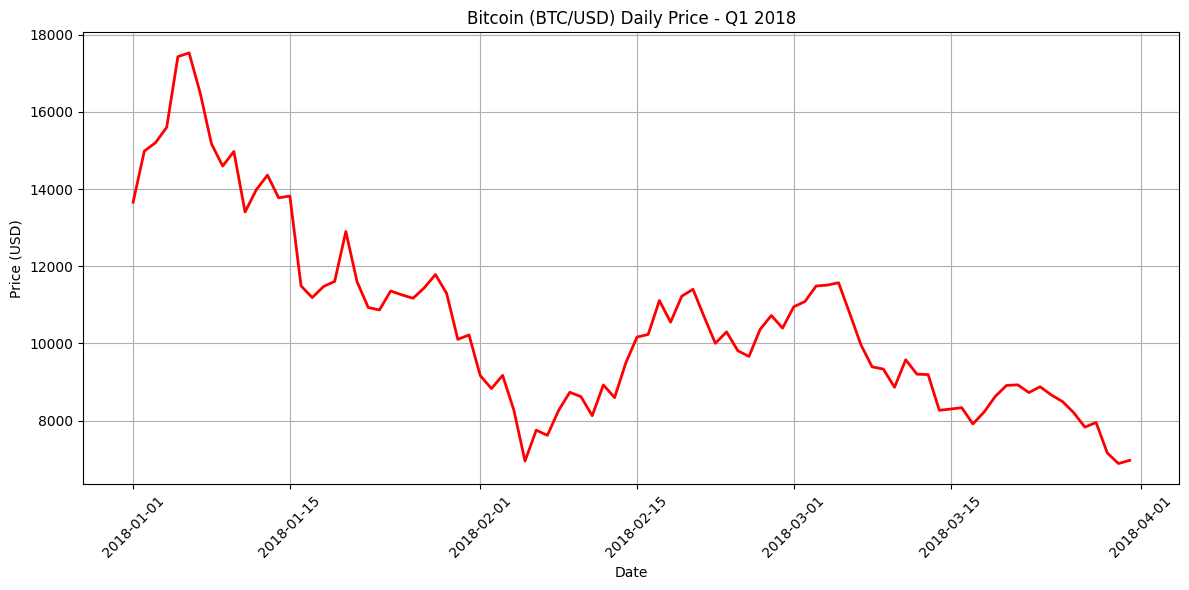

In [83]:
plt.figure(figsize=(12, 6))
plt.plot(merged_df['Date'], merged_df['BTC_Price'], color='red', linewidth=2)
plt.title('Bitcoin (BTC/USD) Daily Price - Q1 2018')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.xticks(rotation=45) # rotate date label for 45 degrees
plt.tight_layout()
plt.savefig('btc_price_trend.png') # save the chart

**Step 4: Advanced Data Analysis: Idetify Wallet Address from Exchanges vs. Treasury based on their "digital footprint**

- The Treasury: Identified by the tx_type column. Look for **Grant Property Tokens**. The sending_address in these rows is the "Money Printer."

- Exchanges: Identified using Centrality Metrics, look for addresses with:

  - **High Frequency of Activity:** Tens of thousands of transactions.

  - **Wide Reach to Unique Partners:** Interacting with 40k+ different "unique" addresses (sending/receiving).

In [86]:
# 0. Look for address of Treasury: locate "Grant Property Tokens"
treasury_txs = tether[tether['tx_type'] == 'Grant Property Tokens']
treasury_wallets = treasury_txs['sending_address'].unique()
print(f"List of Treasury Candidates: {treasury_wallets}")

List of Treasury Candidates: ['3MbYQMMmSkC3AgWkj9FMo5LsPTW1zBTwXL' '1Kaecr9gsYjRDJ8AWqZTBjQ6fd7RUwHynX']


In [88]:
# 1. Calculate unique partners of each sending address
sent_unique = tether.groupby('sending_address')['reference_address'].nunique().rename('unique_partners_out')

# 2. Calculate unique partners of each reference address
received_unique = tether.groupby('reference_address')['sending_address'].nunique().rename('unique_partners_in')

# 3. Calculate the total transaction counts
total_tx_count = tether['sending_address'].value_counts() + tether['reference_address'].value_counts()
total_tx_count = total_tx_count.rename('total_activity')

# 4. Concatenate into a comprehensive list of exchange candidates
exchange_candidates = pd.concat([sent_unique, received_unique, total_tx_count], axis=1).fillna(0)

# 5. Calculate total number of reach to unique partners
exchange_candidates['social_reach'] = exchange_candidates['unique_partners_out'] + exchange_candidates['unique_partners_in']

# 6. Sort value to find out the most possible address of exchanges
top_exchanges = exchange_candidates.sort_values(by='social_reach', ascending=False).head(5)

print("List of Exchange Candidates:")
print(top_exchanges)

List of Exchange Candidates:
                                    unique_partners_out  unique_partners_in  \
1FoWyxwPXuj4C6abqwhjDWdz6D4PZgYRjA              41513.0             44814.0   
1ENVTkd9f5KUkvcKSutiJwdBVPgaPh6ihT              27312.0              7302.0   
1DUb2YYbQA1jjaNYzVXLZ7ZioEhLXtbUru              18093.0             14105.0   
1LAnF8h3qMGx3TSwNUHVneBZUEpwE4gu3D              24769.0              1649.0   
1Po1oWkD2LmodfkBYiAktwh76vkF93LKnh              10089.0             14561.0   

                                    total_activity  social_reach  
1FoWyxwPXuj4C6abqwhjDWdz6D4PZgYRjA        139333.0       86327.0  
1ENVTkd9f5KUkvcKSutiJwdBVPgaPh6ihT         66458.0       34614.0  
1DUb2YYbQA1jjaNYzVXLZ7ZioEhLXtbUru         61329.0       32198.0  
1LAnF8h3qMGx3TSwNUHVneBZUEpwE4gu3D         54080.0       26418.0  
1Po1oWkD2LmodfkBYiAktwh76vkF93LKnh         41385.0       24650.0  


**Step 5: Causal Inference & Financial Modeling**

- Test whether some USDT transaction could affect the price of BTC.
- Find out what type of USDT transaction could affect the price of BTC.


In [48]:
# --- DATA PREPARATION ---
# (Assumes merged_df from Part 3 is available)
# Calculate Log Returns for BTC and Pct Change for USDT
merged_df['BTC_Log_Return'] = np.log(merged_df['BTC_Price'] / merged_df['BTC_Price'].shift(1))
merged_df['USDT_Vol_Pct_Change'] = merged_df['USDT_Volume'].pct_change()
ts_data = merged_df[['BTC_Log_Return', 'USDT_Vol_Pct_Change']].dropna()

**Step 5.1: Stationary Test**

- In time-series analysis, stationarity is the prerequisite for reliable statistical inference. A stationary series is one whose statistical properties (mean, variance, and autocorrelation) are constant over time.

- If time series (variables) are stationary, then we can proceed to test their relationship as following (for example, using VAR, ARIMA, Panel Regression, etc.); If not, then we can test for Cointegration (VECM, Dynamic OLS, etc.).

- Result: p-value < 0.05 suggest that the variables are stationary.

In [92]:
# ---------------------------------------------------------
# STEP 5.1: STATIONARITY TEST (ADF TEST) - The Academic Prerequisite
# ---------------------------------------------------------
# We must ensure p-value < 0.05 to reject the non-stationary null hypothesis.
print("--- Unit Root Test (ADF) ---")
print(f"BTC Return Stationarity p-value: {adfuller(ts_data['BTC_Log_Return'])[1]:.4f}")
print(f"USDT Volume Stationarity p-value: {adfuller(ts_data['USDT_Vol_Pct_Change'])[1]:.4f}")

--- Unit Root Test (ADF) ---
BTC Return Stationarity p-value: 0.0000
USDT Volume Stationarity p-value: 0.0000


**Step 5.2: Lag Selection**

- Lag selection is the process of determining how many past time periods (days, in this case) should be included in the model to explain the current value of a variable.

- Information Criteria:
  - AIC: Predictive Accuracy.
  - BIC: Parsimony and Consistency.
  - FPE (Final Prediction Error): Out-of-sample Performance.
  - HQIC: The Middle Ground. It acts as a compromise for researchers who find AIC too complex and BIC too restrictive.

- Result: In this case, information criteria tests suggest to include lag = 1.

In [93]:
# ---------------------------------------------------------
# STEP 5.2: INFORMATION CRITERIA (AIC/BIC) FOR LAG SELECTION
# ---------------------------------------------------------
# This determines the 'Optimal Lag' (how many past days influence today).
model_select = VAR(ts_data)
# We test lags up to 10 days to find the minimum AIC/BIC score
order_results = model_select.select_order(maxlags=10)
print("\n--- VAR Order Selection (Information Criteria) ---")
print(order_results.summary())

# Choose the lag suggested by AIC (Akaike Information Criterion)
# Usually, AIC suggests a slightly higher lag than BIC, providing better predictive fit.
optimal_lag = order_results.aic
print(f"Optimal Lag Selected via AIC: {optimal_lag}")


--- VAR Order Selection (Information Criteria) ---
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -6.891     -6.831*    0.001017      -6.867
1      -6.945*      -6.765  0.0009635*     -6.873*
2       -6.900      -6.600    0.001008      -6.780
3       -6.931      -6.512   0.0009775      -6.763
4       -6.881      -6.341    0.001029      -6.664
5       -6.801      -6.141    0.001116      -6.537
6       -6.777      -5.998    0.001146      -6.465
7       -6.699      -5.800    0.001243      -6.339
8       -6.684      -5.664    0.001268      -6.276
9       -6.653      -5.513    0.001315      -6.196
10      -6.615      -5.355    0.001376      -6.110
--------------------------------------------------
Optimal Lag Selected via AIC: 1


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


**Step 5.3: Granger Causality Test**

- Result: The p-values are all above 0.05 indicates that **there is no clear lead-lag relationship between daily Tether transaction volumes and Bitcoin price changes during Q1 2018.**

In [94]:
# ---------------------------------------------------------
# Step 5.3: GRANGER CAUSALITY TEST
# ---------------------------------------------------------
# Use the optimal_lag identified above to test for directional influence.
print(f"\n--- Granger Causality (Using Lag={optimal_lag}) ---")
gc_results = grangercausalitytests(ts_data[['BTC_Log_Return', 'USDT_Vol_Pct_Change']], maxlag=[optimal_lag])


--- Granger Causality (Using Lag=1) ---

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0441  , p=0.8341  , df_denom=85, df_num=1
ssr based chi2 test:   chi2=0.0457  , p=0.8307  , df=1
likelihood ratio test: chi2=0.0457  , p=0.8308  , df=1
parameter F test:         F=0.0441  , p=0.8341  , df_denom=85, df_num=1


**Step 5.4: Whale Account Activity Tracking**

- Identify 'Whale' activity through statistical quantile thresholding (99th percentile).
- Whale activity may induce volatile price move on BTC.

In [104]:
# ---------------------------------------------------------
# Step 5.4:WHALE FLOW TRACKING (EMPIRICAL QUANTILE METHOD)
# ---------------------------------------------------------
# Instead of an arbitrary number, we use the 99th percentile (top 1% of transactions).
# This is a statistically robust way to define 'Significant/Extreme' transactions.
threshold_99 = tether_df['amount'].quantile(0.99)
print(f"\nStatistical Threshold (99th Percentile): {threshold_99:,.2f} USDT")

whale_transfers = tether_df[
    (tether_df['sending_address'] == '3MbYQMMmSkC3AgWkj9FMo5LsPTW1zBTwXL') &
    (tether_df['amount'] >= threshold_99)
]
print(f"Number of 'Whale' Transactions found: {len(whale_transfers)}")


Statistical Threshold (99th Percentile): 602,748.10 USDT
Number of 'Whale' Transactions found: 11


**Step 5.5: Pressure Test - Using VAR & Impulse Response Function (IRF)**

- Result: **The results show that on a daily basis, Tether transaction volume does not have a measurable or predictable impact on Bitcoin's price.** While there is a slight mathematical ripple on the first day, it is so small and inconsistent that it falls within the range of normal market noise. This suggests that if any price manipulation is occurring, it is either not driven by daily volume or it happens on a much faster time scale (minutes or hours) that daily data cannot capture.

- Model Selection: Why not Structural VAR? While a standard VAR is purely data-driven, an SVAR will need "economic theoretical framework" onto the model.

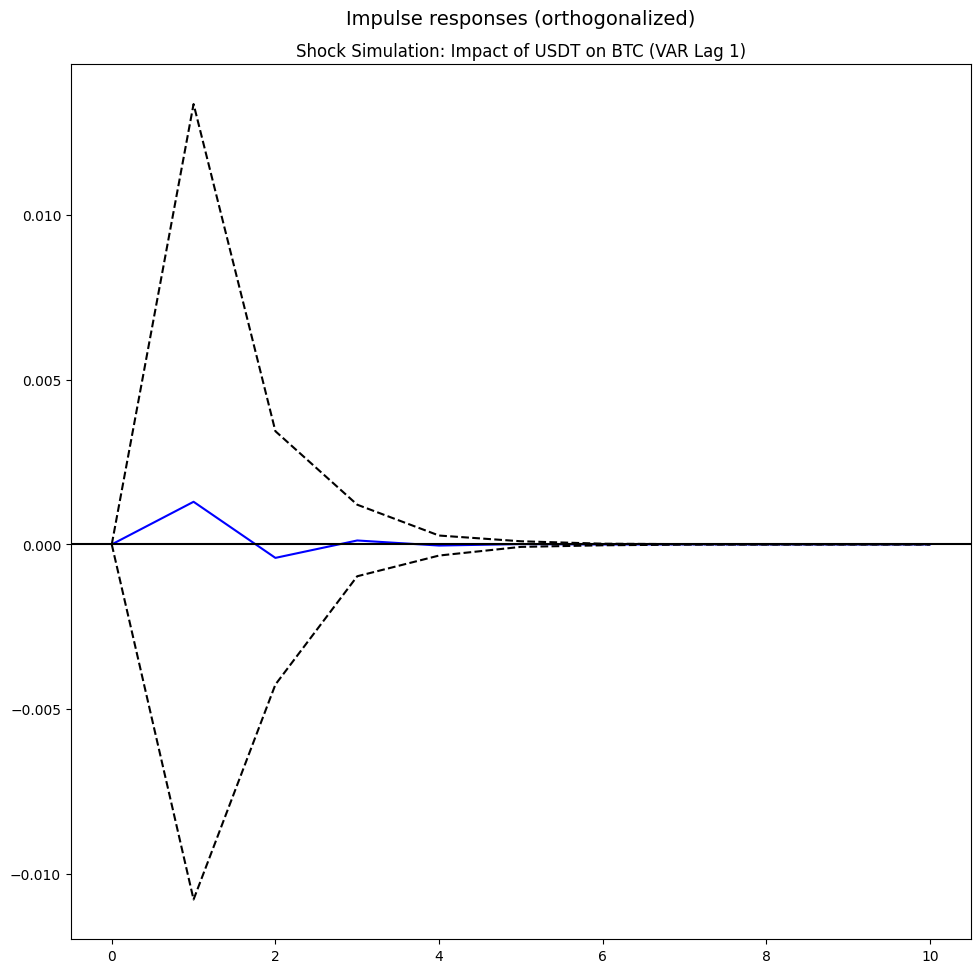

In [103]:
# ---------------------------------------------------------
# Step 5.5: Pressure Test: Orthogonalized Impulse Response Function (IRF)
# ---------------------------------------------------------
# Simulate the impact of a 1-std-dev shock in USDT volume on BTC price
final_model = model_select.fit(optimal_lag)
irf = final_model.irf(10)
irf.plot(orth=True, impulse='USDT_Vol_Pct_Change', response='BTC_Log_Return')
plt.title(f'Shock Simulation: Impact of USDT on BTC (VAR Lag {optimal_lag})')
plt.show()

**Step 6: Model Validation & Robustness Check**

- ARCH-LM Test (Checking for Volatility Clustering)
  - Result: $p \approx 0.93$ and $0.99$ means the model's residuals do not suffer from volatility clustering. This confirms that the standard errors in VAR model are reliable. There is no need to upgrade to a more complex GARCH model.
- Structural Break Test (Chow Test / CUSUM)
  - Result: $p\approx 0.99$ means we fail to reject the null hypothesis of "Parameter Stability." Therefore, despite Bitcoin crashing from $\$17,000$ to $\$7,000$ during Q1 2018, the underlying relationship (or lack thereof) between Tether and Bitcoin remained constant.

In [105]:
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.diagnostic import breaks_cusumolsresid

# 1. ARCH-LM Test for Heteroskedasticity
# (Using residuals from your 'final_model')
resid = final_model.resid
for col in resid.columns:
    arch_test = het_arch(resid[col])
    print(f"ARCH-LM Test for {col} - p-value: {arch_test[1]:.4f}")

# 2. CUSUM Test for Parameter Stability
# (Checking if the model coefficients are stable over time)
cusum_test = breaks_cusumolsresid(resid.values)
print(f"\nCUSUM Test for Structural Stability - p-value: {cusum_test[1]:.4f}")

ARCH-LM Test for BTC_Log_Return - p-value: 0.9295
ARCH-LM Test for USDT_Vol_Pct_Change - p-value: 0.9947

CUSUM Test for Structural Stability - p-value: 0.9908
